In [5]:
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from scipy.ndimage import percentile_filter
import pandas as pd


In [2]:
import re
import numpy as np
from pathlib import Path

major_path = Path(r"C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed")

mapping = {
    'F1': {'0': 'No_motion', '1': 'Motion'},
    'F2': {'0': 'Motion', '1': 'No_motion', '2': 'Anesthesia'},
    'F3': {'0': 'Anesthesia', '1': 'No_motion', '2': 'Motion'},
    'F4': {'0': 'Motion', '1': 'No_motion', '2': 'Motion', '3': 'No_motion', '4': 'Anesthesia'}
}

def list_plane0_folders(root: Path):
    """Return list of dicts: fov, suffix, state, plane0 path."""
    out = []
    for plane0 in root.rglob("plane0"):
        if not plane0.is_dir():
            continue

        parent = plane0.parent.name               # e.g. F4_3
        fov = plane0.parent.parent.name           # e.g. F4

        m = re.match(r"^(F\d+)_(\d+)$", parent)
        if not m:
            continue
        fov2, suffix = m.group(1), m.group(2)
        if fov != fov2:
            continue

        state = mapping.get(fov, {}).get(suffix, "UNKNOWN")
        out.append({"fov": fov, "suffix": suffix, "state": state, "plane0": plane0})

    # stable ordering
    out.sort(key=lambda d: (d["fov"], int(d["suffix"])))
    return out

datasets = list_plane0_folders(major_path)
print("Found plane0 folders:", len(datasets))
for d in datasets:
    print(f"{d['fov']}_{d['suffix']}  {d['state']:>10}   {d['plane0']}")


Found plane0 folders: 13
F1_0   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F1\F1_0\plane0
F1_1      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F1\F1_1\plane0
F2_0      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_0\plane0
F2_1   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_1\plane0
F2_2  Anesthesia   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_2\plane0
F3_0  Anesthesia   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_0\plane0
F3_1   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_1\plane0
F3_2      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_2\plane0
F4_0      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc

In [3]:
import numpy as np
from pathlib import Path

def safe_load(path: Path):
    return np.load(path, allow_pickle=True) if path.exists() else None

# state string used in filenames matches your normalized labels:
# "No_motion", "Motion", "Anesthesia"
for d in datasets:
    s = d["state"]  # already normalized
    p0 = d["plane0"]

    d["adj_raw_path"] = p0 / f"adjacency_{s}_deco.npy"

    d["adj_raw"] = safe_load(d["adj_raw_path"])

print("RAW loaded:", sum(d["adj_raw"] is not None for d in datasets), "/", len(datasets))

# show a few
for d in datasets[:6]:
    print(d["fov"], d["suffix"], d["state"],
          "| raw:", d["adj_raw_path"].name, "->", None if d["adj_raw"] is None else d["adj_raw"].shape)

RAW loaded: 13 / 13
F1 0 No_motion | raw: adjacency_No_motion_deco.npy -> (406, 406)
F1 1 Motion | raw: adjacency_Motion_deco.npy -> (528, 528)
F2 0 Motion | raw: adjacency_Motion_deco.npy -> (496, 496)
F2 1 No_motion | raw: adjacency_No_motion_deco.npy -> (418, 418)
F2 2 Anesthesia | raw: adjacency_Anesthesia_deco.npy -> (320, 320)
F3 0 Anesthesia | raw: adjacency_Anesthesia_deco.npy -> (213, 213)


In [5]:
import numpy as np
import pandas as pd
import networkx as nx

# ----------------------------
# 1) Variants (same as yours)
# ----------------------------
def build_network_variants(W_signed: np.ndarray):
    """
    W_signed: NxN signed correlation-like matrix (undirected, processed)
    Returns non-negative matrices for combined/positive/negative networks.
    """
    W_combined = np.abs(W_signed)
    W_positive = np.where(W_signed > 0, W_signed, 0.0)
    W_negative = np.where(W_signed < 0, -W_signed, 0.0)  # abs of negatives
    return {"combined": W_combined, "positive": W_positive, "negative": W_negative}

def matrix_to_weighted_graph(W: np.ndarray) -> nx.Graph:
    """
    W: NxN matrix with non-negative weights (undirected).
    Builds weighted undirected Graph with edge attribute 'weight'.
    """
    n = W.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    iu = np.triu_indices(n, k=1)
    for i, j in zip(*iu):
        w = float(W[i, j])
        if w > 0:
            G.add_edge(i, j, weight=w)
    return G

# ------------------------------------------
# 2) C/L + degree-preserving weighted nulls
# ------------------------------------------
def compute_C_L_with_null(G: nx.Graph, n_rand=1000, seed=42):
    """
    Returns:
      C_emp, L_emp, C_rand_mean, L_rand_mean, C_rand_all, L_rand_all
    Notes:
      - Uses largest connected component.
      - Uses distance = 1/weight for weighted shortest paths.
      - Null: configuration model from degree sequence + random weight resampling.
    """
    if G.number_of_edges() == 0:
        return (np.nan, np.nan, np.nan, np.nan, np.array([]), np.array([]))

    # largest connected component
    if not nx.is_connected(G):
        Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    else:
        Gc = G.copy()

    # clustering
    C_emp = nx.average_clustering(Gc, weight="weight")

    # weighted shortest path via distance=1/weight
    H = nx.Graph()
    H.add_nodes_from(Gc.nodes())
    for u, v, data in Gc.edges(data=True):
        w = data.get("weight", 1.0)
        if w > 0:
            H.add_edge(u, v, distance=1.0 / w)

    try:
        L_emp = nx.average_shortest_path_length(H, weight="distance")
    except nx.NetworkXError:
        return (C_emp, np.nan, np.nan, np.nan, np.array([]), np.array([]))

    deg_seq = [d for _, d in Gc.degree()]
    weights = np.array([data["weight"] for _, _, data in Gc.edges(data=True)], dtype=float)

    rng = np.random.default_rng(seed)
    C_rand_all, L_rand_all = [], []

    for _ in range(n_rand):
        # degree-preserving randomization
        R = nx.configuration_model(deg_seq, seed=int(rng.integers(1_000_000_000)))
        R = nx.Graph(R)
        R.remove_edges_from(nx.selfloop_edges(R))

        if R.number_of_edges() == 0:
            continue

        # assign random weights sampled from empirical weights
        rand_ws = rng.choice(weights, size=R.number_of_edges(), replace=True)
        for (u, v), w in zip(R.edges(), rand_ws):
            R[u][v]["weight"] = float(w)

        # largest CC
        if not nx.is_connected(R):
            Rc = R.subgraph(max(nx.connected_components(R), key=len)).copy()
        else:
            Rc = R

        # clustering in null
        C_r = nx.average_clustering(Rc, weight="weight")

        # path length in null
        Hr = nx.Graph()
        Hr.add_nodes_from(Rc.nodes())
        for u, v, data in Rc.edges(data=True):
            w = data.get("weight", 1.0)
            if w > 0:
                Hr.add_edge(u, v, distance=1.0 / w)
        try:
            L_r = nx.average_shortest_path_length(Hr, weight="distance")
        except nx.NetworkXError:
            continue

        C_rand_all.append(C_r)
        L_rand_all.append(L_r)

    C_rand_all = np.asarray(C_rand_all, dtype=float)
    L_rand_all = np.asarray(L_rand_all, dtype=float)

    C_rand_mean = np.nan if len(C_rand_all) == 0 else float(np.nanmean(C_rand_all))
    L_rand_mean = np.nan if len(L_rand_all) == 0 else float(np.nanmean(L_rand_all))

    return C_emp, L_emp, C_rand_mean, L_rand_mean, C_rand_all, L_rand_all

def small_world_sigma(C_emp, L_emp, C_rand_mean, L_rand_mean):
    if any(np.isnan([C_emp, L_emp, C_rand_mean, L_rand_mean])) or C_rand_mean <= 0 or L_rand_mean <= 0:
        return np.nan
    return (C_emp / C_rand_mean) / (L_emp / L_rand_mean)

def null_p_and_z(sigma_emp, sigma_rand_all):
    """
    Empirical p-value vs null distribution, and z-score.
    p: fraction of null >= empirical (one-sided, "more small-world than null")
    """
    sigma_rand_all = np.asarray(sigma_rand_all, dtype=float)
    sigma_rand_all = sigma_rand_all[np.isfinite(sigma_rand_all)]
    if not np.isfinite(sigma_emp) or len(sigma_rand_all) == 0:
        return np.nan, np.nan, 0
    p = (np.sum(sigma_rand_all >= sigma_emp) + 1) / (len(sigma_rand_all) + 1)
    z = (sigma_emp - float(np.mean(sigma_rand_all))) / float(np.std(sigma_rand_all, ddof=1) + 1e-12)
    return float(p), float(z), int(len(sigma_rand_all))

# ----------------------------------------------------
# 3) Run ALL datasets from your existing `datasets` list
# ----------------------------------------------------
# Assumes:
# - you already built `datasets` with keys: fov, suffix, state, adj_raw
# - state strings are like: "No_motion", "Motion", "Anesthesia"
net_types = ["combined", "positive", "negative"]
rows = []

for d in datasets:
    W_signed = d.get("adj_raw", None)
    if W_signed is None:
        continue

    # safety: ensure numpy array float
    W_signed = np.asarray(W_signed, dtype=float)

    # (optional) enforce symmetry if tiny numerical drift exists
    W_signed = (W_signed + W_signed.T) / 2.0
    np.fill_diagonal(W_signed, 0.0)

    variants = build_network_variants(W_signed)

    for net_type in net_types:
        Wv = variants[net_type]
        G = matrix_to_weighted_graph(Wv)

        C_emp, L_emp, C_rand_mean, L_rand_mean, C_rand_all, L_rand_all = \
            compute_C_L_with_null(G, n_rand=50, seed=42)

        sigma_emp = small_world_sigma(C_emp, L_emp, C_rand_mean, L_rand_mean)

        # your "null sigma" idea but using your empirical C,L against null C,L
        valid = (C_rand_all > 0) & (L_rand_all > 0)
        sigma_rand_all = ((C_emp / C_rand_all[valid]) / (L_emp / L_rand_all[valid])) if np.any(valid) else np.array([])

        p_null, z_null, n_null = null_p_and_z(sigma_emp, sigma_rand_all)

        n = G.number_of_nodes()
        e = G.number_of_edges()
        density = (2 * e) / (n * (n - 1)) if n > 1 else np.nan

        rows.append({
            "fov": d["fov"],
            "suffix": int(d["suffix"]),
            "state": d["state"],
            "net_type": net_type,
            "N": n,
            "E": e,
            "density": density,
            "C": C_emp,
            "L": L_emp,
            "C_rand_mean": C_rand_mean,
            "L_rand_mean": L_rand_mean,
            "sigma": sigma_emp,
            "p_null": p_null,
            "z_null": z_null,
            "n_null": n_null,
        })

df_sw = pd.DataFrame(rows).sort_values(["fov", "suffix", "net_type"])
print(df_sw.head())
print("Rows:", len(df_sw))

  fov  suffix      state  net_type    N      E   density         C         L  \
0  F1       0  No_motion  combined  406  12333  0.150009  0.359444  1.897707   
2  F1       0  No_motion  negative  406   1178  0.014328  0.020769  2.993423   
1  F1       0  No_motion  positive  406  11155  0.135681  0.370466  1.985355   
3  F1       1     Motion  combined  528  20870  0.150006  0.304042  1.861193   
5  F1       1     Motion  negative  528   4592  0.033006  0.053777  2.540621   

   C_rand_mean  L_rand_mean     sigma    p_null    z_null  n_null  
0     0.218401     1.889722  1.638874  0.529412 -0.007524      50  
2     0.099744     3.057084  0.212651  0.549020 -0.084985      50  
1     0.206439     1.914907  1.730874  0.549020 -0.009043      50  
3     0.182857     1.870275  1.670842  0.431373 -0.004564      50  
5     0.120749     2.593756  0.454677  0.490196 -0.043787      50  
Rows: 39


In [4]:
import matplotlib.pyplot as plt
'''
for net_type in ["combined", "positive", "negative"]:
    tmp = df_sw[df_sw["net_type"] == net_type].copy()

    # box-ish view via scatter (no seaborn)
    states = list(tmp["state"].unique())
    xmap = {s:i for i,s in enumerate(states)}
    xs = tmp["state"].map(xmap).values
    ys = tmp["sigma"].values

    plt.figure()
    plt.scatter(xs, ys)
    plt.xticks(range(len(states)), states, rotation=20)
    plt.ylabel("Small-worldness σ")
    plt.title(f"σ by state ({net_type})")
    plt.tight_layout()
    plt.show()
'''

'\nfor net_type in ["combined", "positive", "negative"]:\n    tmp = df_sw[df_sw["net_type"] == net_type].copy()\n\n    # box-ish view via scatter (no seaborn)\n    states = list(tmp["state"].unique())\n    xmap = {s:i for i,s in enumerate(states)}\n    xs = tmp["state"].map(xmap).values\n    ys = tmp["sigma"].values\n\n    plt.figure()\n    plt.scatter(xs, ys)\n    plt.xticks(range(len(states)), states, rotation=20)\n    plt.ylabel("Small-worldness σ")\n    plt.title(f"σ by state ({net_type})")\n    plt.tight_layout()\n    plt.show()\n'

In [6]:
df_sw = pd.read_excel(r"C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\small_world_0219.xlsx")

In [7]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

In [8]:
df_sw["state"] = df_sw["state"].str.replace("_", " ", regex=False)

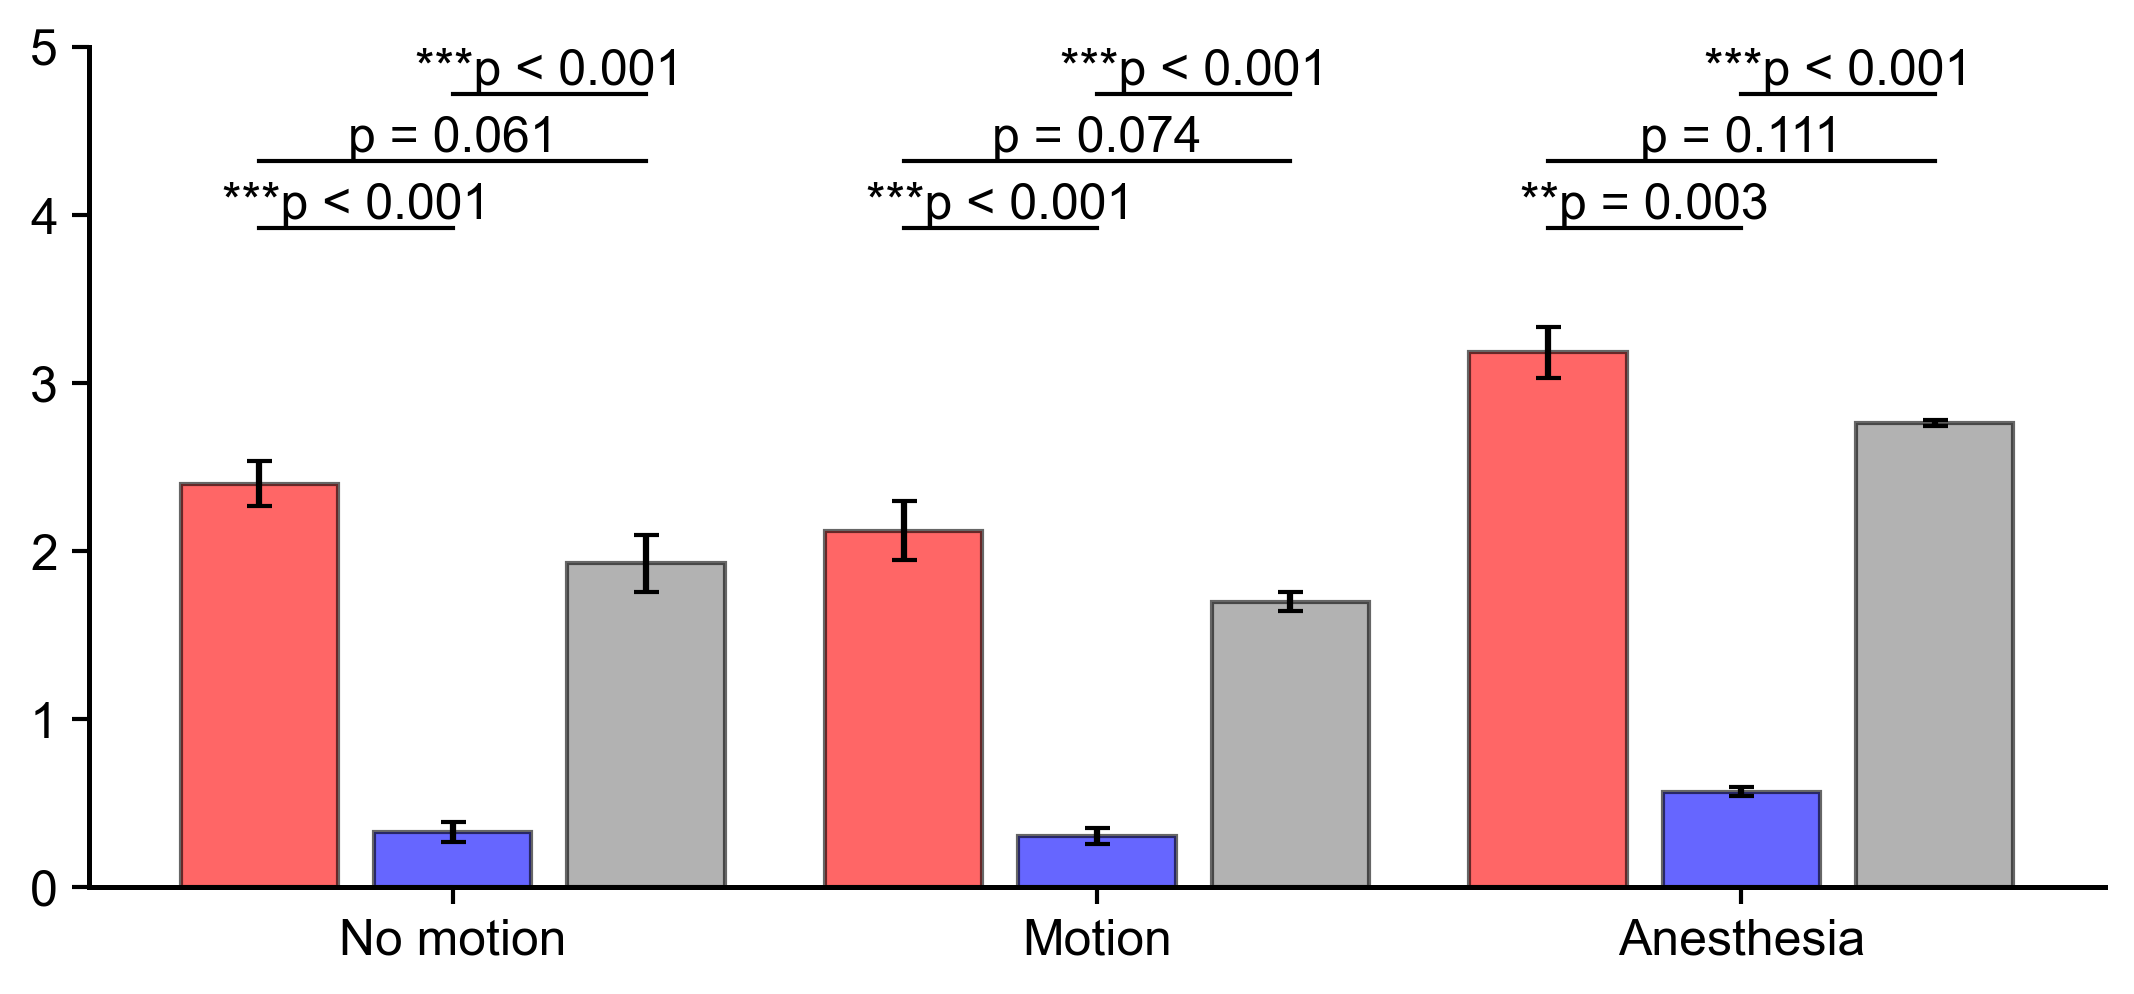

In [12]:
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_types = ["combined", "positive", "negative"]
bar_width = 0.22
inner_gap = 0.05
group_gap = 0.9
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + h * 1.1, text, ha="center", va="bottom")

def welch_p(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return ttest_ind(a, b, equal_var=False).pvalue

# ---- x positions ----
indices = np.arange(len(states)) * group_gap
offsets = {
    "positive": -(bar_width + inner_gap),
    "negative": 0.0,
    "combined": +(bar_width + inner_gap),
}

# ---- plot ----
fig_sigma_all, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")
rng = np.random.default_rng(0)
y_base = 4
# Determine a global max Y value for significance lines
global_sw = df_sw['sigma'].max()
fixed_sig_line_y = global_sw * 1.05 # Adjust multiplier as needed
h_fixed = fixed_sig_line_y * 0.02 # Fixed height for the line itself
step_fixed = fixed_sig_line_y * 0.1 # Fixed step between lines

for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_sw[(df_sw["state"] == s) & (df_sw["net_type"] == nt)]
        vals = sub["sigma"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

        
        #ax.scatter(np.full(len(vals), x_pos) + jitter, vals,s=28, facecolors="none", edgecolors="black", linewidths=1)

    # ---- within-state significance bars (3 pairwise comparisons) ----
    # pairwise p-values
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    # Use fixed y-coordinates for significance lines
    add_sig_line(ax, xs["positive"], xs["negative"], y=y_base * 0.98, h=0, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y_base*1.08, h=0, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y_base * 1.18, h=0, p=p_neg_com)
    #add_sig_line(ax, xs["positive"], xs["combined"], y=fixed_sig_line_y + step_fixed*1, h=0, p=p_pos_com)
    #add_sig_line(ax, xs["negative"], xs["combined"], y=fixed_sig_line_y + step_fixed*2, h=0, p=p_neg_com)


# labels
#ax.set_xticks(indices)
ax.set_xticks(indices)
ax.set_ylim(0,5)
ax.set_xticklabels(states)
#ax.set_ylabel("Community number K",y=0.6)

# legend
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]
#ax.legend(handles=legend_handles, frameon=False,
          #loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)

paper_axes(ax)
# plt.title("Modularity Q for all samples with SEM")

plt.show()

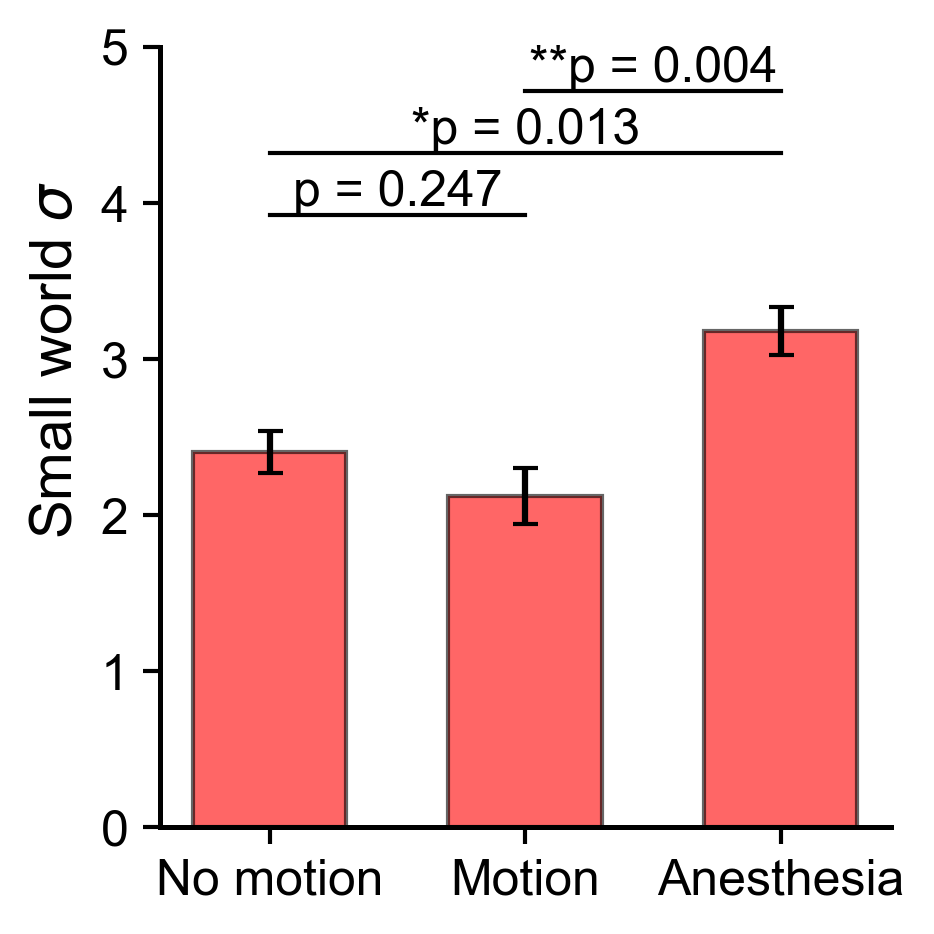

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_type_to_plot = "positive"

def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + h * 1.1, text, ha="center", va="bottom")

def welch_p(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return ttest_ind(a, b, equal_var=False).pvalue

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_pos, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['sigma'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
ax.set_ylabel(r"Small world $\sigma$",y=0.6)
# fig.savefig("Q_positive.svg")
plt.show()


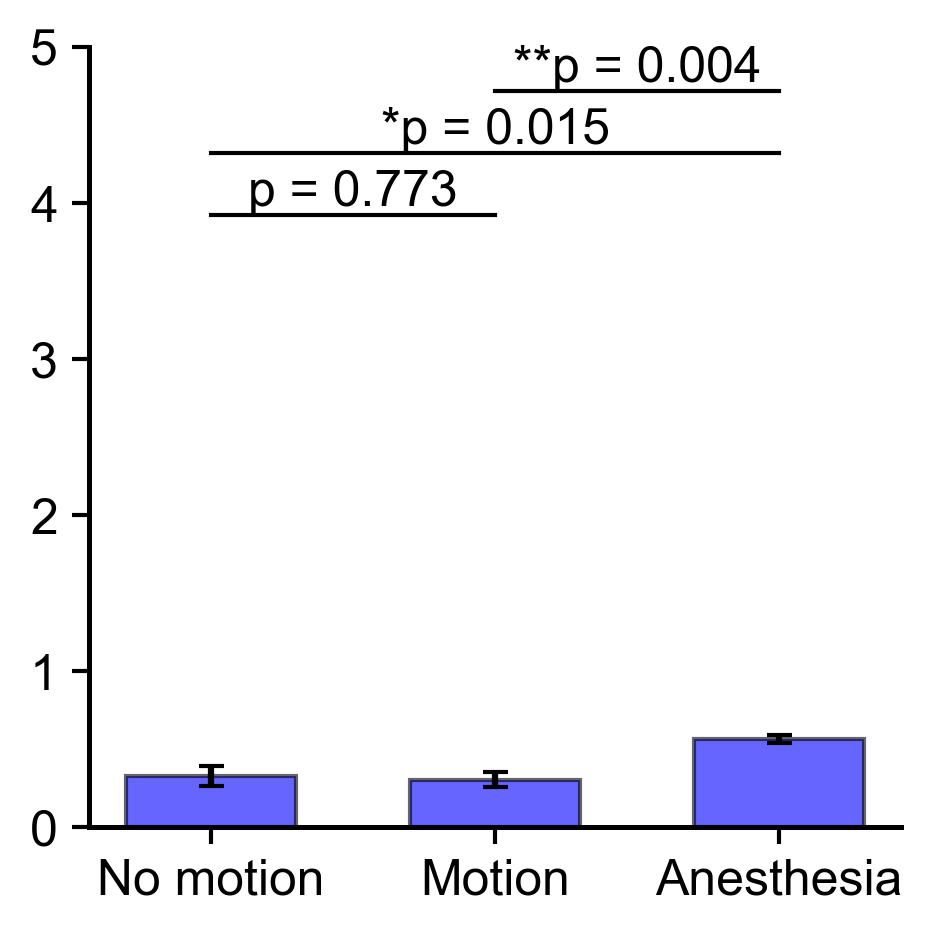

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_type_to_plot = "negative"

def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + h * 1.1, text, ha="center", va="bottom")

def welch_p(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return ttest_ind(a, b, equal_var=False).pvalue

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_neg, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['sigma'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
# ax.set_ylabel(r"Small world $\sigma$",y=0.6)
# fig.savefig("Q_positive.svg")
plt.show()


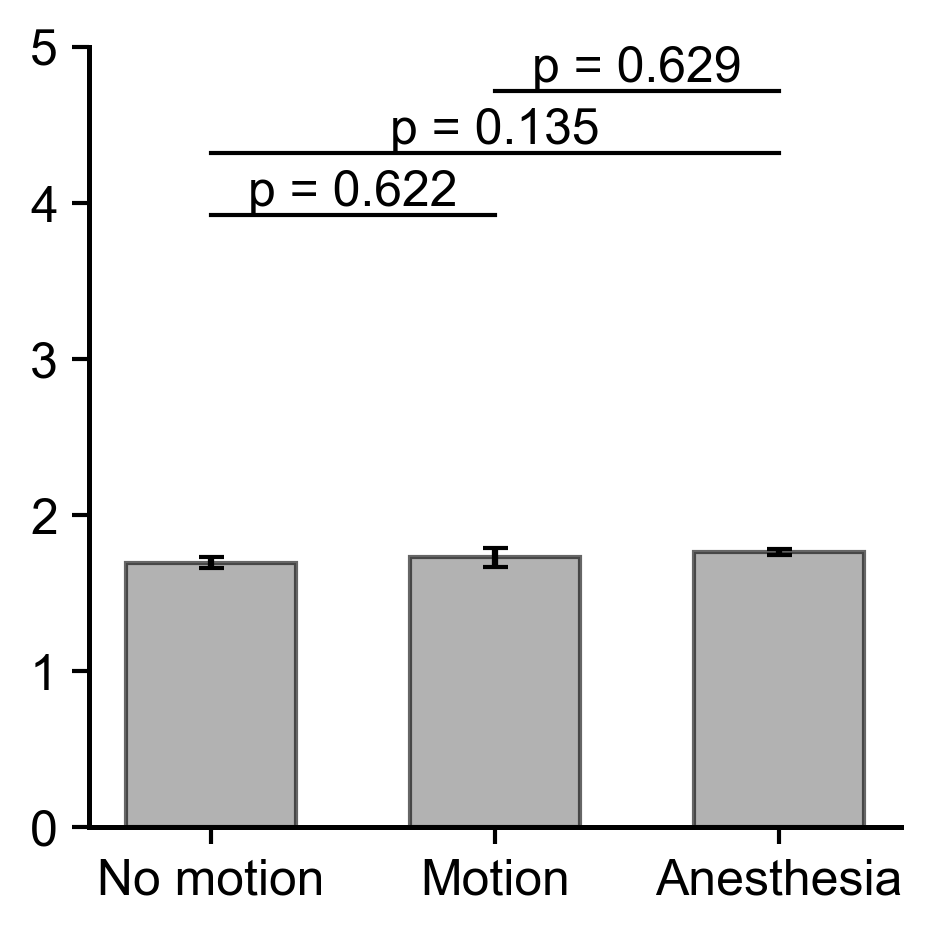

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_type_to_plot = "combined"

def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + h * 1.1, text, ha="center", va="bottom")

def welch_p(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return ttest_ind(a, b, equal_var=False).pvalue

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_comb, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['sigma'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
# ax.set_ylabel(r"Small world $\sigma$",y=0.6)
# fig.savefig("Q_positive.svg")
plt.show()


In [15]:
from datetime import datetime
FIG_DIR = Path(r"C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed/figures")
td = datetime.today().strftime("%m_%d_%y")
fig_path = FIG_DIR / td

# 2. Create the directory (this returns None, so we do it on its own line)
fig_path.mkdir(parents=True, exist_ok=True)

In [67]:
fig_sigma_all.savefig(fig_path/'sigma_all.svg')

In [68]:
fig_pos.savefig(fig_path/'sigma_pos.svg')

In [69]:
fig_neg.savefig(fig_path/'sigma_neg.svg')

In [70]:
fig_comb.savefig(fig_path/'sigma_comb.svg')

In [76]:
df_sw[(df_sw['state'] == 'Motion')&(df_sw['net_type'] == 'combined')]['sigma'].describe()

count    5.000000
mean     1.696715
std      0.126836
min      1.525944
25%      1.638874
50%      1.698550
75%      1.754768
max      1.865439
Name: sigma, dtype: float64

#### Clustering coefficient

In [37]:
df_sw = pd.read_excel(r"C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\cluster_path_0223.xlsx")
df_sw["state"] = df_sw["state"].str.replace("_", " ", regex=False)

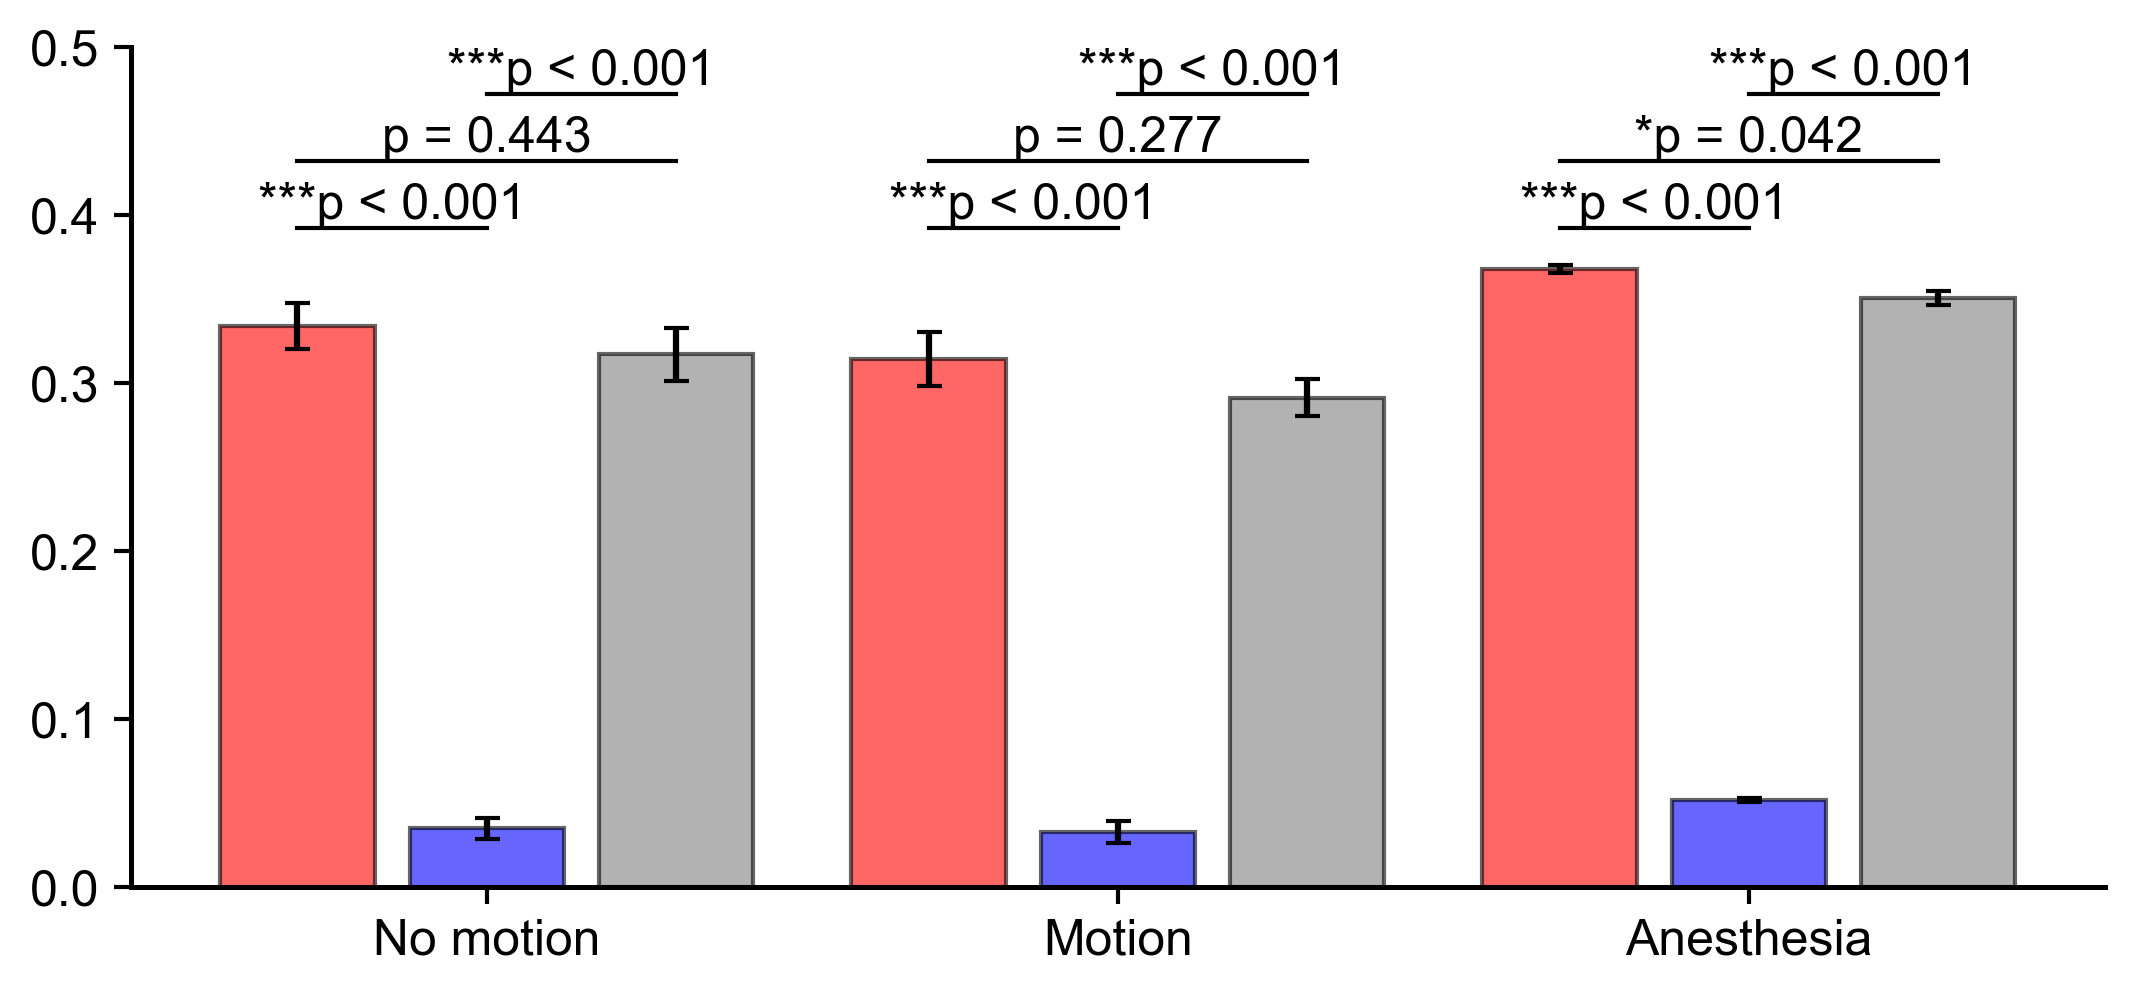

In [113]:
states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})
net_types = ["combined", "positive", "negative"]
bar_width = 0.22
inner_gap = 0.05
group_gap = 0.9
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + h * 1.1, text, ha="center", va="bottom")

def welch_p(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return ttest_ind(a, b, equal_var=False).pvalue

# ---- x positions ----
indices = np.arange(len(states)) * group_gap
offsets = {
    "positive": -(bar_width + inner_gap),
    "negative": 0.0,
    "combined": +(bar_width + inner_gap),
}

# ---- plot ----
fig_C_all, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")
rng = np.random.default_rng(0)
y_base = 0.4
# Determine a global max Y value for significance lines
global_C = df_sw['C'].max()
fixed_sig_line_y = global_C * 1.05 # Adjust multiplier as needed
h_fixed = fixed_sig_line_y * 0.02 # Fixed height for the line itself
step_fixed = fixed_sig_line_y * 0.1 # Fixed step between lines

for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_sw[(df_sw["state"] == s) & (df_sw["net_type"] == nt)]
        vals = sub["C"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

        
        #ax.scatter(np.full(len(vals), x_pos) + jitter, vals,s=28, facecolors="none", edgecolors="black", linewidths=1)

    # ---- within-state significance bars (3 pairwise comparisons) ----
    # pairwise p-values
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    # Use fixed y-coordinates for significance lines
    add_sig_line(ax, xs["positive"], xs["negative"], y=y_base * 0.98, h=0, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y_base*1.08, h=0, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y_base * 1.18, h=0, p=p_neg_com)
    #add_sig_line(ax, xs["positive"], xs["combined"], y=fixed_sig_line_y + step_fixed*1, h=0, p=p_pos_com)
    #add_sig_line(ax, xs["negative"], xs["combined"], y=fixed_sig_line_y + step_fixed*2, h=0, p=p_neg_com)


# labels
#ax.set_xticks(indices)
ax.set_xticks(indices)
ax.set_ylim(0,0.5)
ax.set_xticklabels(states)
#ax.set_ylabel("Community number K",y=0.6)

# legend
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]
#ax.legend(handles=legend_handles, frameon=False,
          #loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)

paper_axes(ax)
# plt.title("Modularity Q for all samples with SEM")

plt.show()

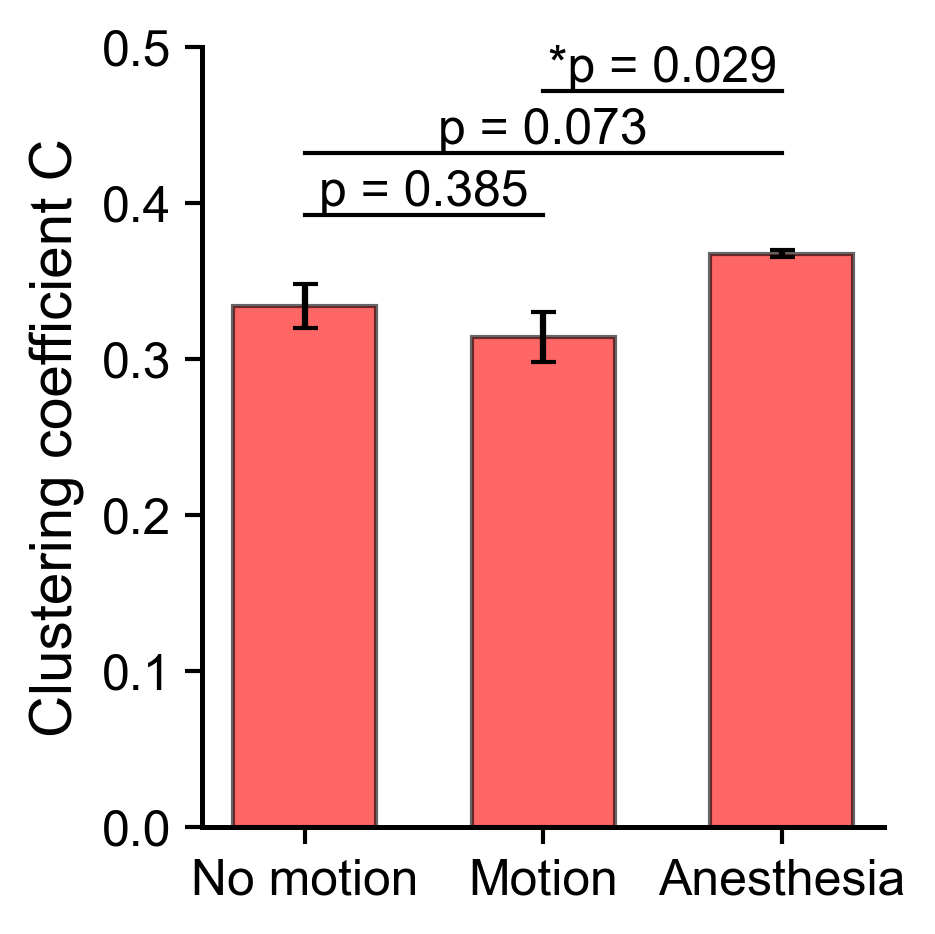

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_type_to_plot = "positive"

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_C_pos, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['C'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 0.4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,0.5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
ax.set_ylabel(r"Clustering coefficient C",y=0.5)
# fig.savefig("Q_positive.svg")
plt.show()


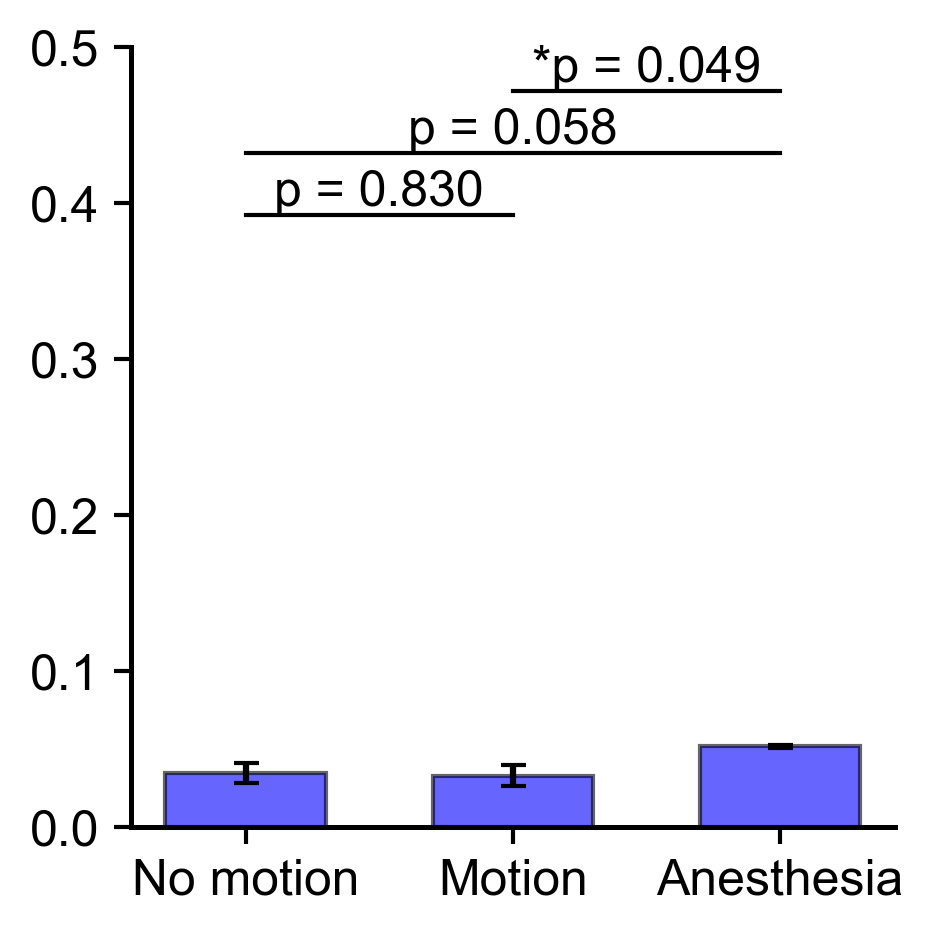

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_type_to_plot = "negative"

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_C_neg, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['C'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 0.4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,0.5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
# ax.set_ylabel(r"Small world $\sigma$",y=0.6)
# fig.savefig("Q_positive.svg")
plt.show()


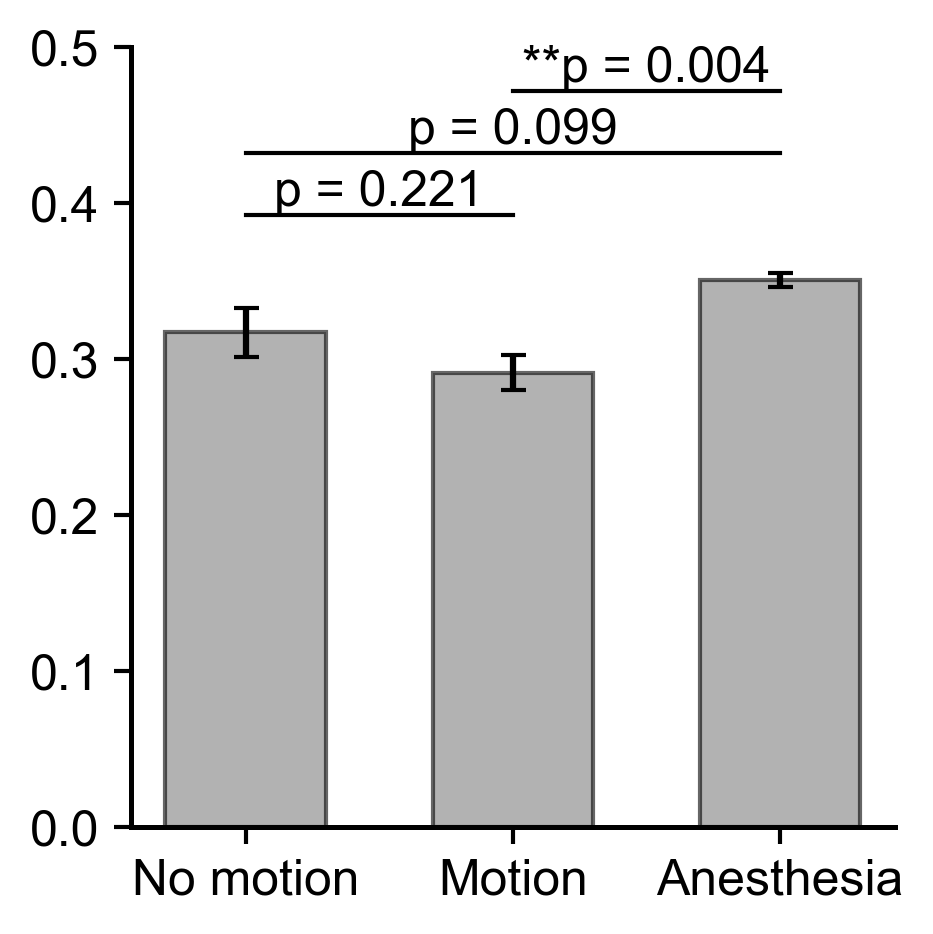

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

net_type_to_plot = "combined"

def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + h * 1.1, text, ha="center", va="bottom")

def welch_p(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return ttest_ind(a, b, equal_var=False).pvalue

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_C_comb, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['C'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 0.4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,0.5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
# ax.set_ylabel(r"Small world $\sigma$",y=0.6)
# fig.savefig("Q_positive.svg")
plt.show()


In [42]:
fig_C_all.savefig(fig_path/"C_all.svg")

In [44]:
fig_C_pos.savefig(fig_path/"C_pos.svg")
fig_C_neg.savefig(fig_path/"C_neg.svg")
fig_C_comb.savefig(fig_path/"C_comb.svg")

#### L

In [6]:
df_sw = pd.read_excel(r"C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\cluster_path_0223.xlsx")
df_sw["state"] = df_sw["state"].str.replace("_", " ", regex=False)

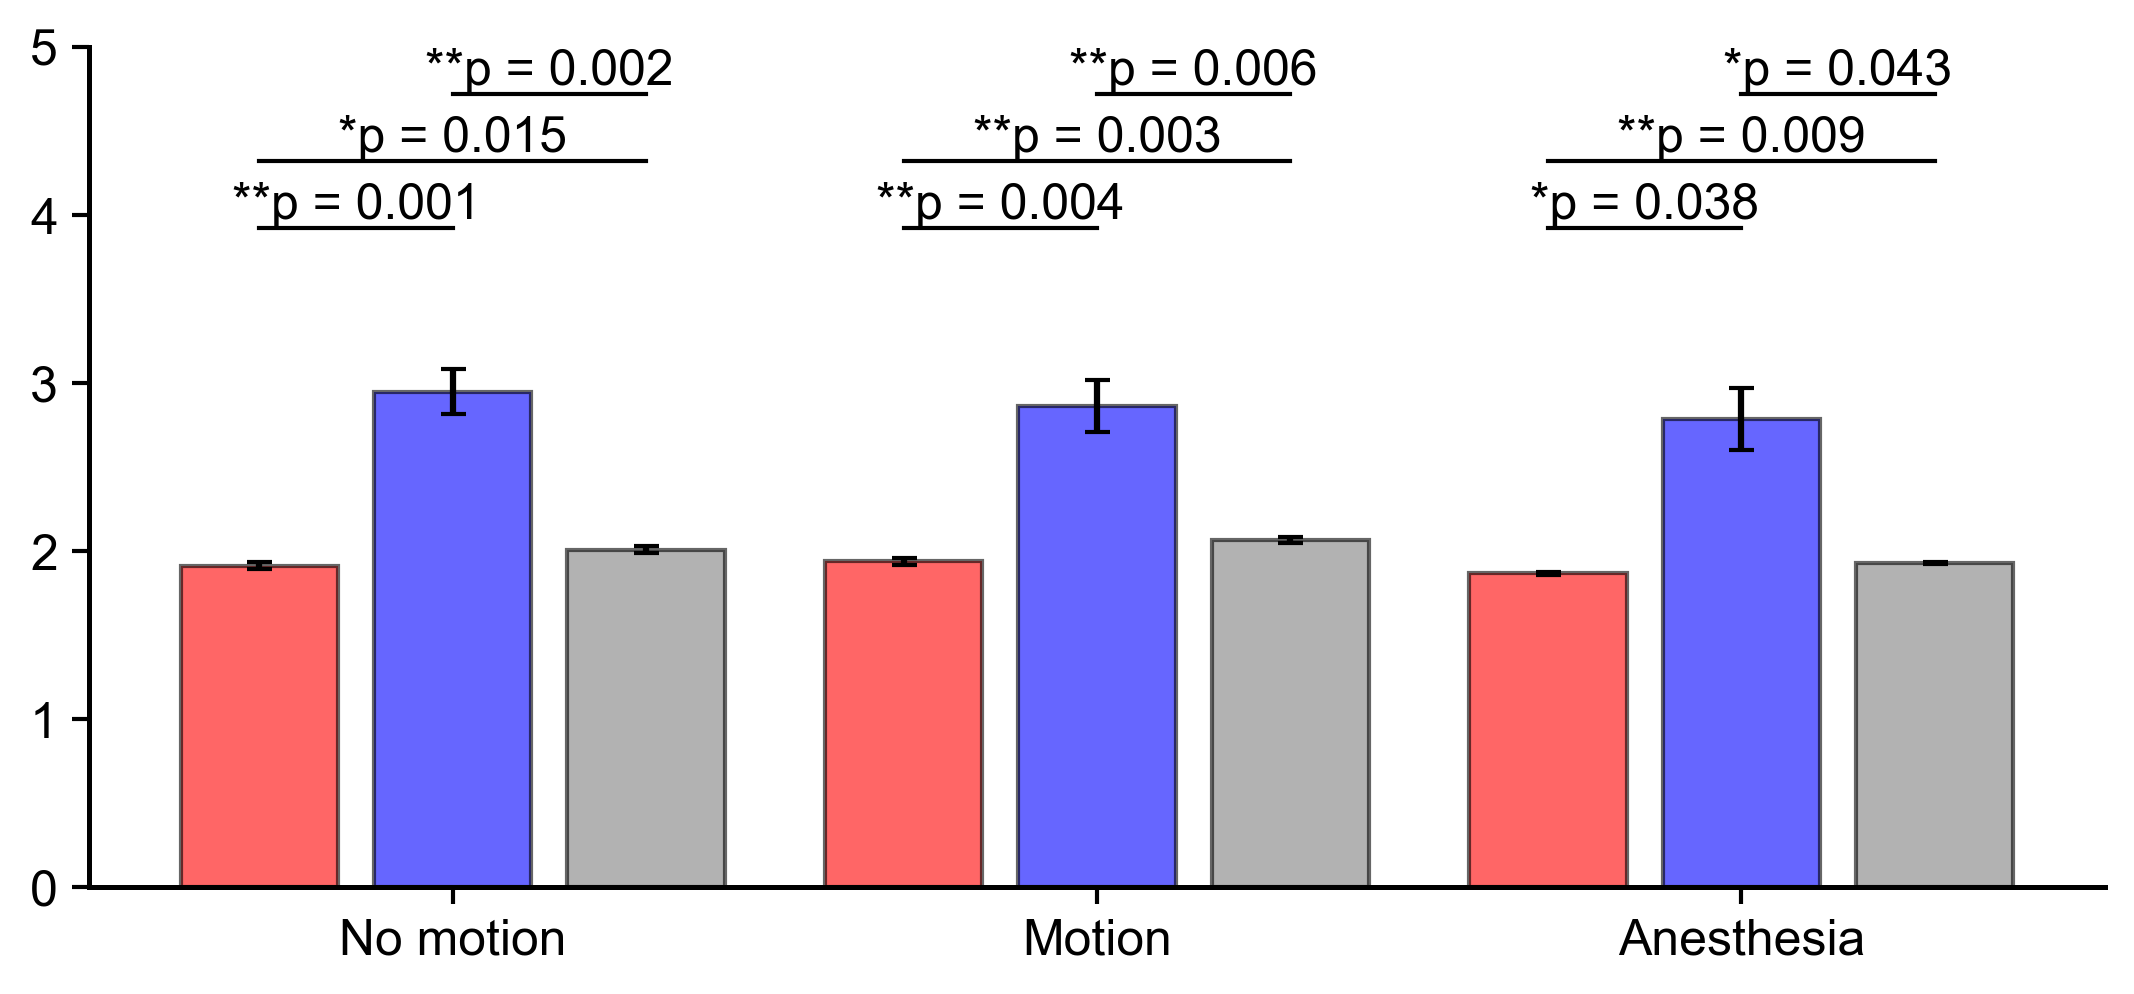

In [137]:
states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})
net_types = ["combined", "positive", "negative"]
bar_width = 0.22
inner_gap = 0.05
group_gap = 0.9
from matplotlib.patches import Patch
from scipy.stats import ttest_ind

# ---- x positions ----
indices = np.arange(len(states)) * group_gap
offsets = {
    "positive": -(bar_width + inner_gap),
    "negative": 0.0,
    "combined": +(bar_width + inner_gap),
}

# ---- plot ----
fig_L_all, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")
rng = np.random.default_rng(0)
y_base = 4
# Determine a global max Y value for significance lines
global_C = df_sw['L'].max()
fixed_sig_line_y = global_C * 1.05 # Adjust multiplier as needed
h_fixed = fixed_sig_line_y * 0.02 # Fixed height for the line itself
step_fixed = fixed_sig_line_y * 0.1 # Fixed step between lines

for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_sw[(df_sw["state"] == s) & (df_sw["net_type"] == nt)]
        vals = sub["L"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

        
        #ax.scatter(np.full(len(vals), x_pos) + jitter, vals,s=28, facecolors="none", edgecolors="black", linewidths=1)

    # ---- within-state significance bars (3 pairwise comparisons) ----
    # pairwise p-values
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    # Use fixed y-coordinates for significance lines
    add_sig_line(ax, xs["positive"], xs["negative"], y=y_base * 0.98, h=0, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y_base*1.08, h=0, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y_base * 1.18, h=0, p=p_neg_com)
    #add_sig_line(ax, xs["positive"], xs["combined"], y=fixed_sig_line_y + step_fixed*1, h=0, p=p_pos_com)
    #add_sig_line(ax, xs["negative"], xs["combined"], y=fixed_sig_line_y + step_fixed*2, h=0, p=p_neg_com)


# labels
#ax.set_xticks(indices)
ax.set_xticks(indices)
ax.set_ylim(0,5)
ax.set_xticklabels(states)
#ax.set_ylabel("Community number K",y=0.6)

# legend
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]
#ax.legend(handles=legend_handles, frameon=False,
          #loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)

paper_axes(ax)
# plt.title("Modularity Q for all samples with SEM")

plt.show()

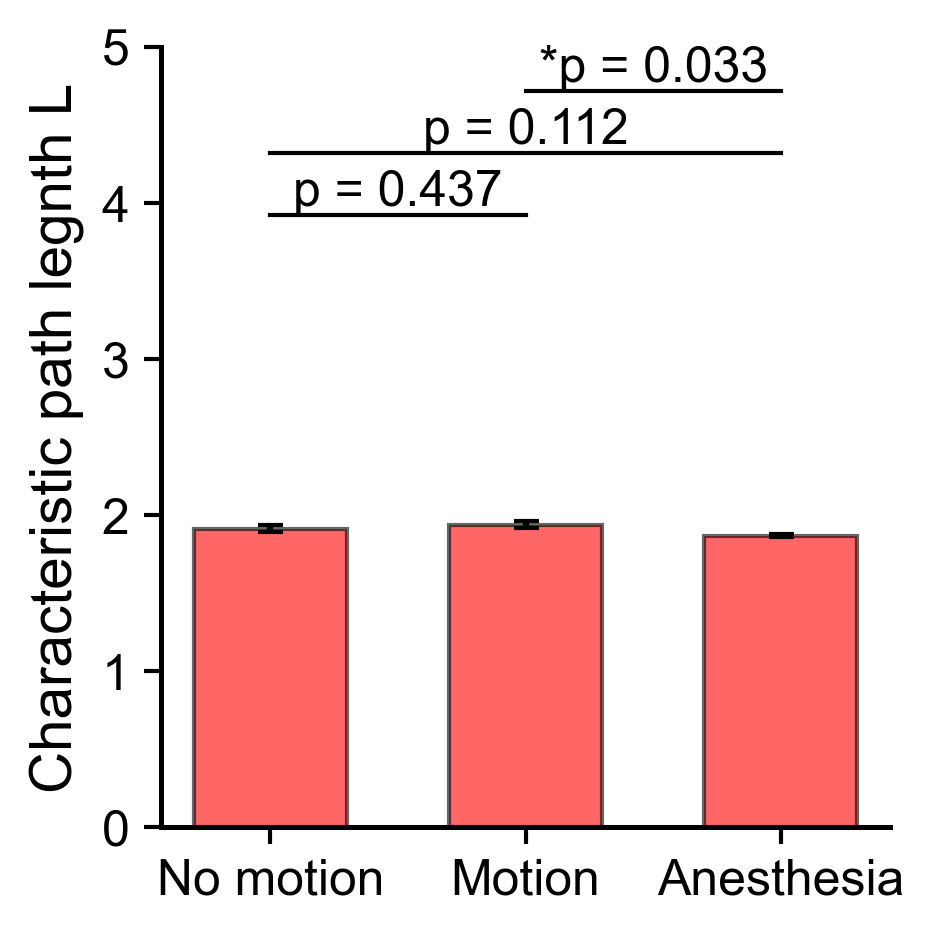

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

states = ["No motion", "Motion", "Anesthesia"]
colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_type_to_plot = "positive"

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_L_pos, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['L'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
ax.set_ylabel(r"Characteristic path legnth L",y=0.5)
# fig.savefig("Q_positive.svg")
plt.show()


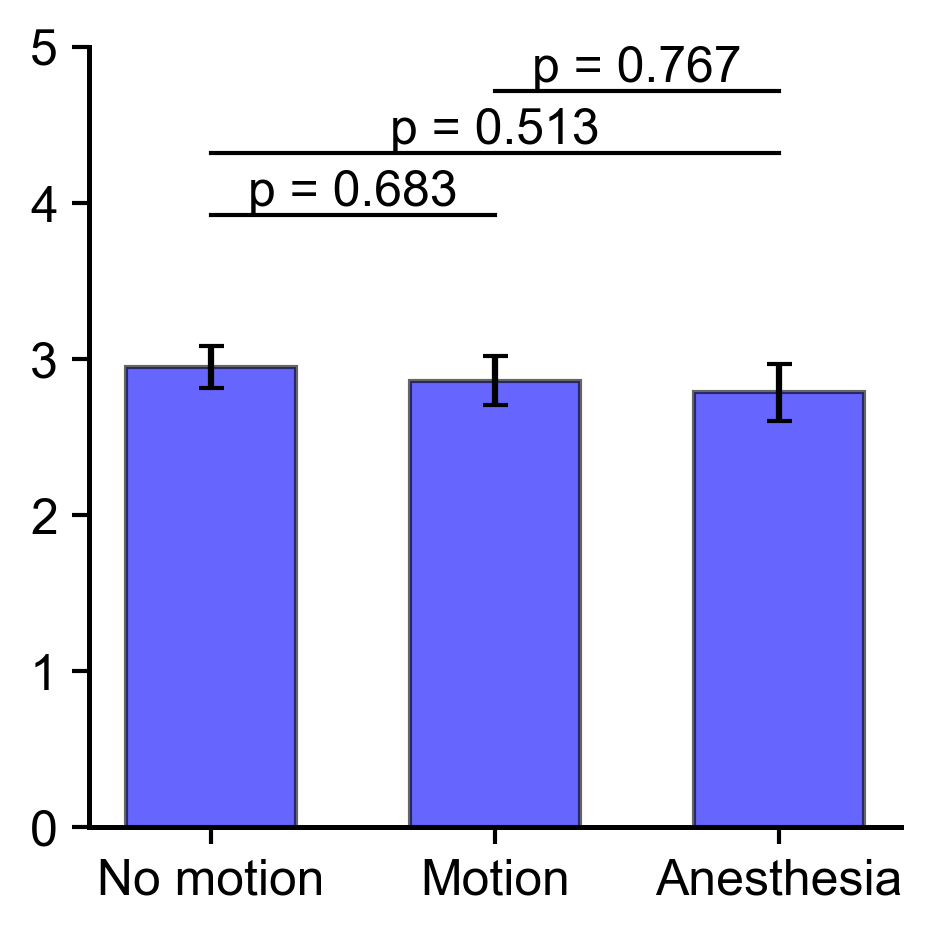

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

states = ["No motion", "Motion", "Anesthesia"]

colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_type_to_plot = "negative"

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_L_neg, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['L'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
#ax.set_ylabel(r"Characteristic path legnth L",y=0.5)
# fig.savefig("Q_positive.svg")
plt.show()


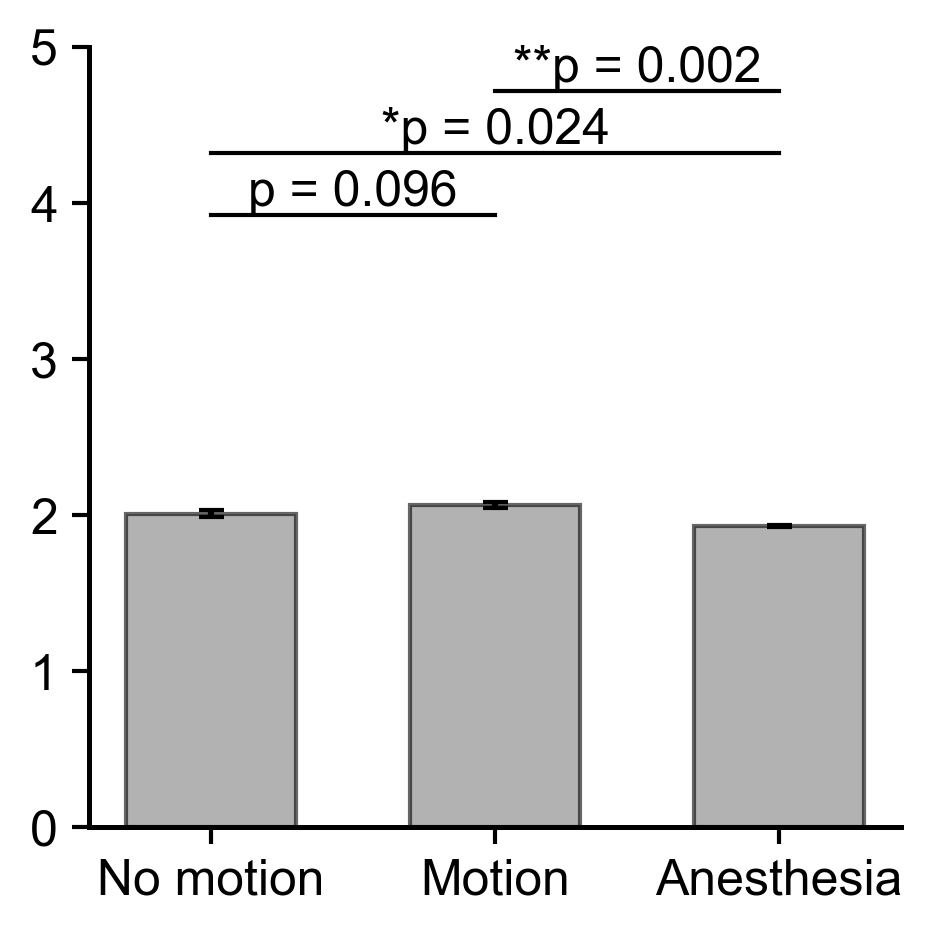

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})


colors = {
    "positive": "red",
    "negative": "blue",
    "combined": "gray"
}
net_type_to_plot = "combined"

# Filter df_Q for the specified network type
df_filtered = df_sw[df_sw['net_type'] == net_type_to_plot]

fig_L_comb, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
x_positions = np.arange(len(states))

means = []
sems = []
vals_by_state = {}

for i, state in enumerate(states):
    vals = df_filtered[df_filtered['state'] == state]['L'].dropna().values
    vals_by_state[state] = vals
    m, se = mean_sem(vals)
    means.append(m)
    sems.append(se)

    ax.bar(
        x_positions[i], m, width=0.6,
        yerr=se, capsize=3,
        edgecolor="black", linewidth=1,
        facecolor=colors[net_type_to_plot], alpha=0.6
    )
    # Add individual data points (jittered scatter)
    #jitter = np.random.normal(0, 0.05, size=len(vals))
    #ax.scatter(np.full(len(vals), x_positions[i]) + jitter, vals,s=28,
               #facecolors="none", edgecolors="black", linewidths=1)

# ax.set_xticks(['No motion', 'Motion', 'Anesthesia'])
# ax.set_xticklabels(states)
ax.set_xticks(x_positions)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
#ax.set_ylabel("Modularity Q (classic, weighted)")
#ax.set_title(f'Modularity Q: {net_type_to_plot} Network', y=1.05)

# Add significance lines between states
y_base = 4
# Calculate p-values between states
p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
p_m_a = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])
ax.set_ylim(0,5)
add_sig_line(ax, x_positions[0], x_positions[1], y=y_base*0.98, h=0, p=p_nm_m)
add_sig_line(ax, x_positions[0], x_positions[2], y=y_base*1.08, h=0, p=p_nm_a)
add_sig_line(ax, x_positions[1], x_positions[2], y=y_base*1.18, h=0, p=p_m_a)

paper_axes(ax)
# fig.tight_layout()
#ax.set_ylabel(r"Characteristic path legnth L",y=0.5)
# fig.savefig("Q_positive.svg")
plt.show()


In [144]:
fig_L_all.savefig(fig_path / 'L_all.svg')
fig_L_pos.savefig(fig_path / 'L_pos.svg')
fig_L_neg.savefig(fig_path / 'L_neg.svg')
fig_L_comb.savefig(fig_path / 'L_comb.svg')

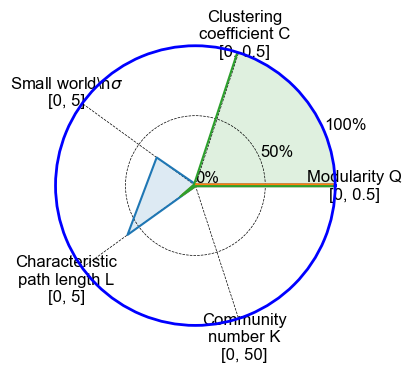

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------
# Data
# ---------------------------------------------
labels = ['Clustering\ncoefficient C', r'Small world\n$\sigma$',
          'Characteristic\npath length L', 'Community\nnumber K','Modularity Q']
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

#no_motion = [15.4, 0.16, 2.65, 21, 0.38, 8]
#motion = [12, 0.19, 2.95, 23.5, 0.32, 8]
#anesthesia = [16.9, 0.21, 3.17, 19, 0.45, 8]

no_motion = [0.0046, 1.71, 3.0, 0.20, 37]
motion = [0.00463, 0.051, 0.57, 0.19, 38]
anesthesia = [2.21, 0.06, 0.66,  0.22, 38]

#no_motion = [17.3,0.12, 2.84, 23, 0.28, 8]
#motion = [13.1, 0.09 ,2.67, 25.5, 0.21, 8]
#anesthesia = [19.8,0.13, 3.06, 21.1, 0.28, 8]

data_sets = {
    'No motion': no_motion,
    'Motion': motion,
    'Anesthesia': anesthesia
}

# ---------------------------------------------
# Per-axis ranges (EDIT THESE AS NEEDED)
# ---------------------------------------------
# small-worldness: [0, 5]
# clustering coefficient: [0, 1]
# characteristic path: [0, 10]
# modularity: [0, 1]
mins = [0, 0, 0, 0, 0]
#maxs = [20, 0.3, 4, 25, 0.5, 10]
maxs = [0.5, 5, 5, 50, 0.5]
#
# ---------------------------------------------
# Radar chart setup
# ---------------------------------------------
num_vars = len(labels)
angles = np.linspace(0+2*np.pi/num_vars, 2 * np.pi+2*np.pi/num_vars, num_vars, endpoint=False).tolist()
angles += angles[:1]

def normalize(values):
    """Normalize each axis to 0–1 using its own min/max."""
    return [(v - mn) / (mx - mn) if mx != mn else 0
            for v, mn, mx in zip(values, mins, maxs)]

# ---------------------------------------------
# Plot
# ---------------------------------------------
fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(4, 4),layout='constrained')

for name, vals in data_sets.items():
    norm_vals = normalize(vals)
    norm_vals += norm_vals[:1]  # close the loop
    ax.plot(angles, norm_vals, label=name)
    ax.tick_params(axis='x') # Set x-axis tick label size
    ax.tick_params(axis='y')
    ax.fill(angles, norm_vals, alpha=0.15)

# Axis labels (include ranges)
pretty_labels = [
    f'{lab}\n[{mn}, {mx}]'
    for lab, mn, mx in zip(labels, mins, maxs)
]

ax.set_xticks(angles[:-1])
ax.set_xticklabels(pretty_labels)
# Change the circular grid (radial) lines
ax.yaxis.grid(True, color="black", linestyle="--", linewidth=0.5)

# Change the spoke (angle) lines
ax.xaxis.grid(True, color="black", linestyle="--", linewidth=0.5)
ax.spines['polar'].set_color("blue")
ax.spines['polar'].set_linewidth(2)



# Radial scale
ax.set_yticks([0.0, 0.5, 1.0])
ax.set_yticklabels(['0%', '50%', '100%'])
ax.set_ylim(0, 1)

#plt.title("Comparison of Brain States (Normalized Scales)", y=1.1)
#plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=11)

#plt.savefig('Radar_negative.svg')

plt.show()


In [10]:
df_sw[(df_sw['state'] == 'Motion')&(df_sw['net_type'] == 'combined')]['L'].describe()

count    5.000000
mean     2.064116
std      0.045313
min      2.034757
25%      2.046871
50%      2.047170
75%      2.047170
max      2.144611
Name: L, dtype: float64

In [84]:
df_sw.head()

,Unnamed: 0,fov,suffix,state,net_type,N,E,density,C,L,C_rand_mean,L_rand_mean,sigma,p_null,z_null,n_null
0,0,F1,0,No motion,combined,406,12333,0.150009,0.319818,1.985355,0.185761,1.914907,1.638874,0.529412,-0.007524,50
1,2,F1,0,No motion,negative,406,1178,0.014328,0.039926,2.993423,0.104154,3.057084,0.212651,0.549020,-0.084985,50
2,1,F1,0,No motion,positive,406,11155,0.135681,0.340077,1.897707,0.133319,1.889722,1.730874,0.549020,-0.009043,50
3,3,F1,1,Motion,combined,528,20870,0.150006,0.274042,1.949751,0.182857,1.904274,1.670842,0.431373,-0.004564,50
4,5,F1,1,Motion,negative,528,4592,0.033006,0.020769,2.540621,0.099744,2.593756,0.454677,0.490196,-0.043787,50


In [109]:
import pandas as pd

# Calculate gamma (normalized clustering) and lambda (normalized path length)
df_sw['gamma'] = df_sw['C'] / df_sw['C_rand_mean']
df_sw['lambda_ratio'] = df_sw['L'] / df_sw['L_rand_mean'] # Renamed to avoid confusion with lambda functions

# Display the first few rows to verify the calculation
print(df_sw[['state', 'net_type', 'gamma', 'lambda_ratio', 'sigma']].head())

# Optional: Export this for your supplementary file
# df_sw[['state', 'net_type', 'gamma', 'lambda_ratio', 'sigma']].to_csv("Supplementary_Table_S1.csv")

       state  net_type     gamma  lambda_ratio     sigma
0  No motion  combined  1.721661      1.036789  1.638874
1  No motion  negative  0.383332      0.979176  0.212651
2  No motion  positive  2.550851      1.004226  1.730874
3     Motion  combined  1.498666      1.023881  1.670842
4     Motion  negative  0.208222      0.979514  0.454677


In [110]:
df_sw[['state', 'net_type', 'gamma', 'lambda_ratio', 'sigma']]

,state,net_type,gamma,lambda_ratio,sigma
0,No motion,combined,1.721661,1.036789,1.638874
1,No motion,negative,0.383332,0.979176,0.212651
2,No motion,positive,2.550851,1.004226,1.730874
3,Motion,combined,1.498666,1.023881,1.670842
4,Motion,negative,0.208222,0.979514,0.454677
5,Motion,positive,2.182019,0.995144,2.274497
6,Motion,combined,1.515842,1.007870,1.525944
7,Motion,negative,0.562525,0.984245,0.571530
8,Motion,positive,2.256282,0.993379,2.238662
9,No motion,combined,1.582861,1.017007,1.592264


C:\Users\gp00062\AppData\Local\Temp\ipykernel_36440\666853495.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.2}` instead.

  sns.barplot(
C:\Users\gp00062\AppData\Local\Temp\ipykernel_36440\666853495.py:12: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.2}` instead.

  sns.barplot(


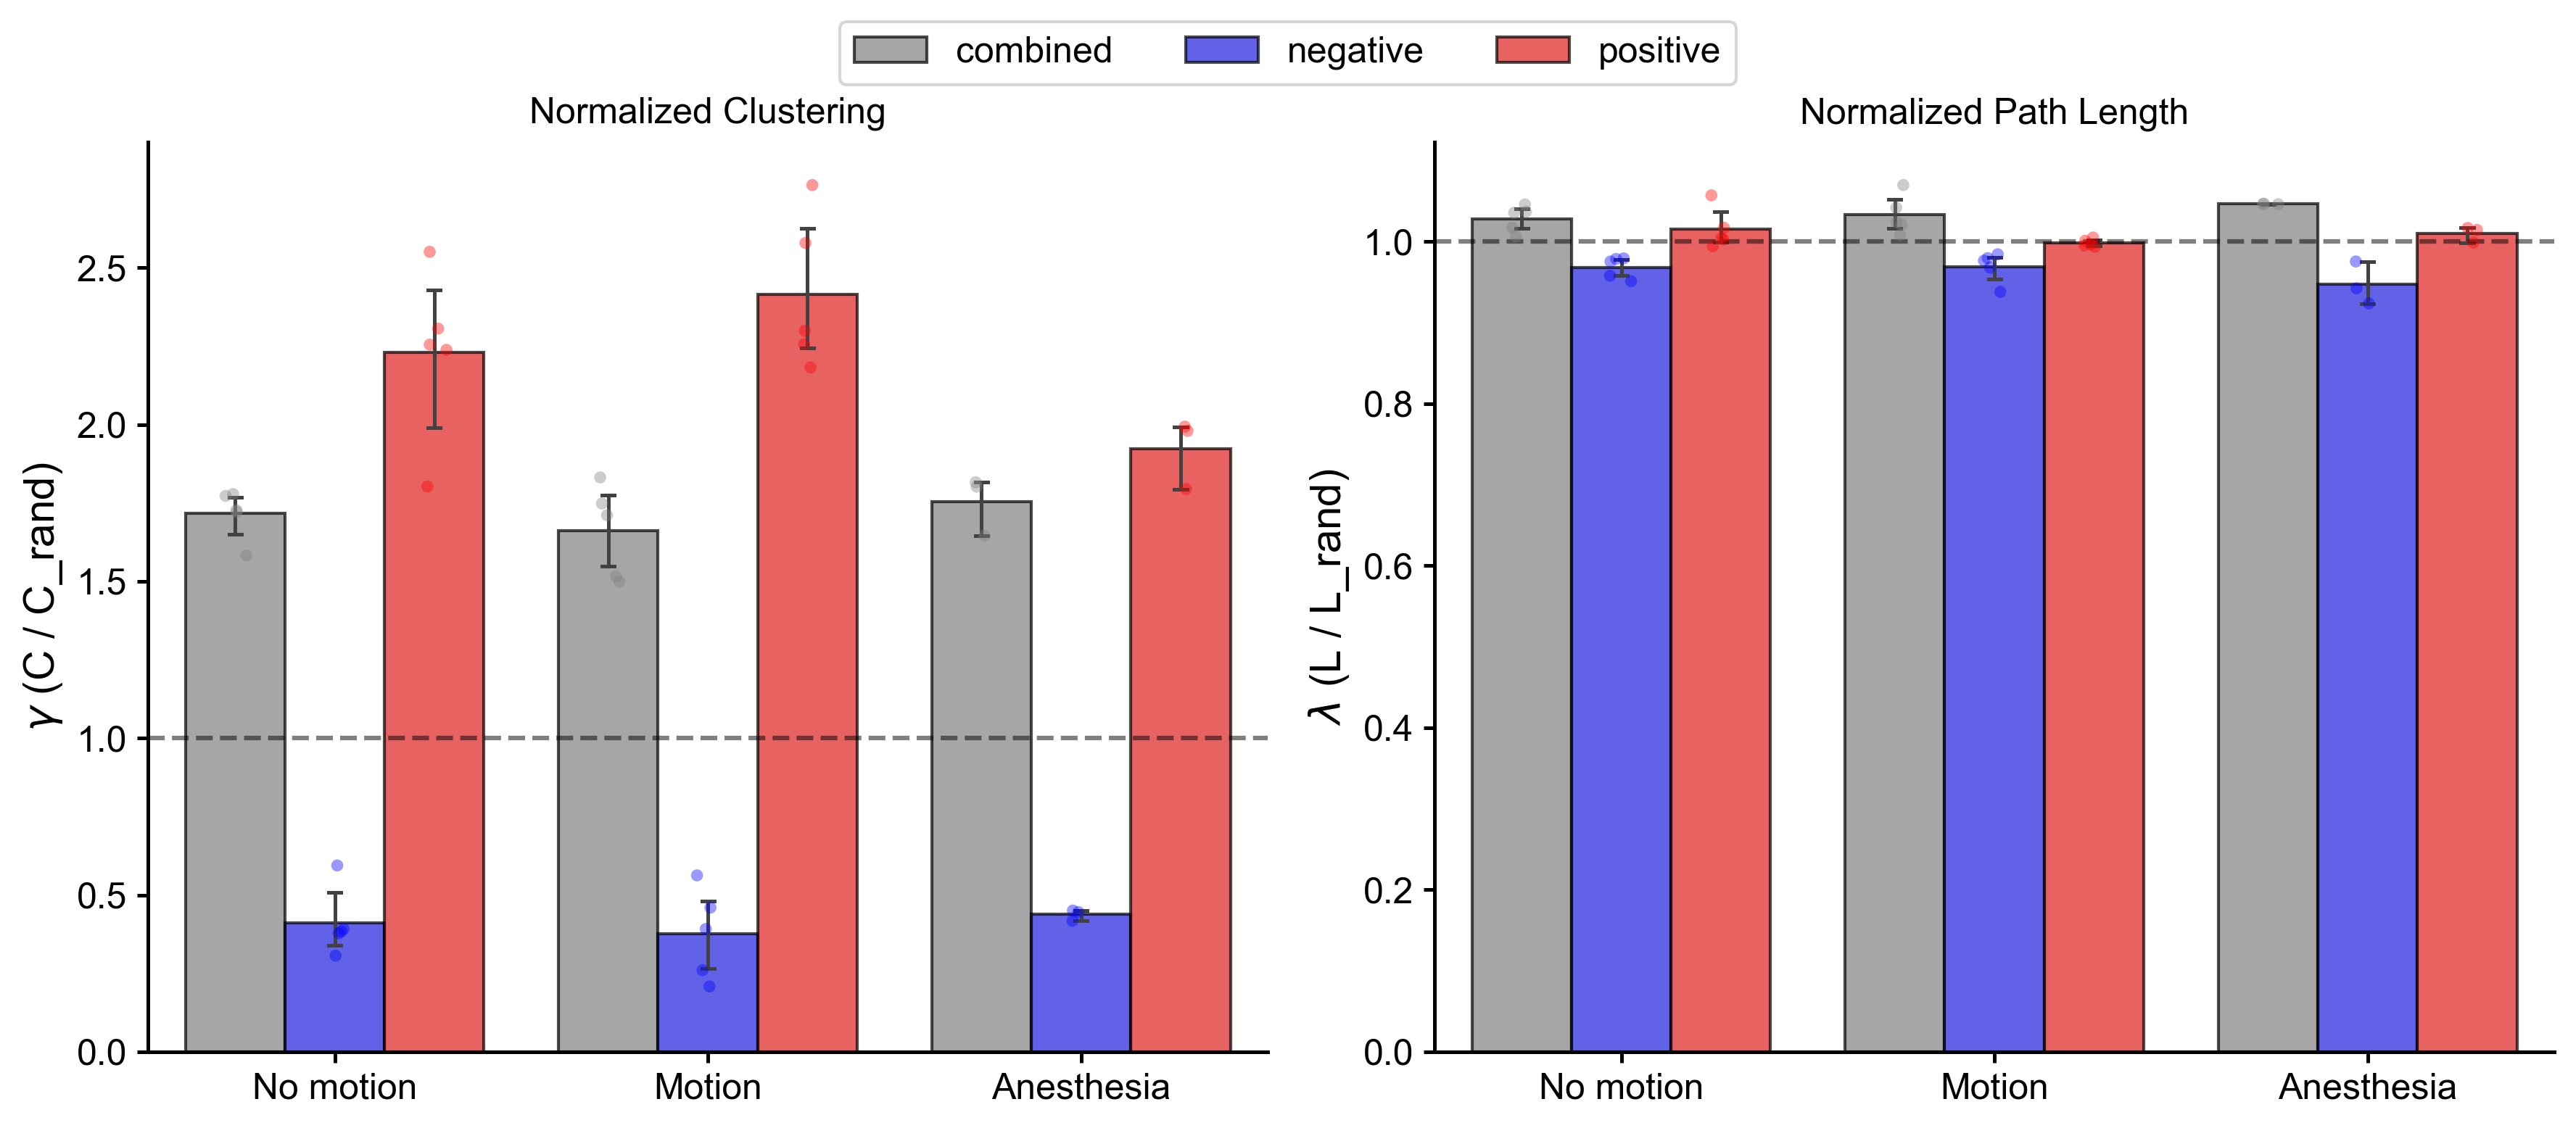

In [111]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Assuming df_sw is your dataframe
# Define colors to match your main figures
colors = {"positive": "red", "negative": "blue", "combined": "gray"}
states_order = ["No motion", "Motion", "Anesthesia"]

def plot_supplementary_sw(df, metric, ylabel, title, ax):
    sns.barplot(
        data=df, x="state", y=metric, hue="net_type", 
        order=states_order, palette=colors, ax=ax, 
        edgecolor="black", alpha=0.7, capsize=.1, errwidth=1.2
    )
    # Add the individual data points (jitter)
    sns.stripplot(
        data=df, x="state", y=metric, hue="net_type", 
        order=states_order, palette=colors, ax=ax, 
        dodge=True, color="black", alpha=0.4, size=4
    )
    
    # Clean up legend and axes
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.get_legend().remove()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Plot Gamma (Normalized Clustering)
plot_supplementary_sw(df_sw, "gamma", "$\gamma$ (C / C_rand)", "Normalized Clustering", ax1)
ax1.axhline(1, color='black', linestyle='--', alpha=0.5) # Baseline

# Plot Lambda (Normalized Path Length)
plot_supplementary_sw(df_sw, "lambda_ratio", "$\lambda$ (L / L_rand)", "Normalized Path Length", ax2)
ax2.axhline(1, color='black', linestyle='--', alpha=0.5) # Baseline

# Create a single legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles[0:3], labels[0:3], loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)

plt.tight_layout()
plt.show()

In [90]:
df_sw[['state', 'net_type', 'gamma', 'lambda_ratio', 'sigma']].to_excel("Table_S1.xlsx")